In [1]:
!pip install scikit-plot

In [2]:
import pandas as pd
import numpy as np
import matplotlib, matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn import metrics

from scipy.stats import pearsonr

import matplotlib.ticker as ticker
import matplotlib.pyplot as plt

from itertools import cycle

import seaborn as sns
from seaborn import cubehelix_palette
sns.set()

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [3]:
def print_accuracy_and_classification_report(labels, prediction):
    print('Cross validation accuracy:')
    print('\t', metrics.accuracy_score(labels, prediction))
    print('\nCross validation classification report\n')
    print(metrics.classification_report(labels, prediction))

def predict_classes(probabilities):
    """Predict class labels from probabilities
    Args:
        probabilities (numpy.array): model output for each class
    Returns:
        (numpy.array): Model predicted class labels
    """
    predicted = np.array(
        [list(a).index(max(list(a))) for a in list(probabilities)])
    label_binarizer = preprocessing.LabelBinarizer()

    label_binarizer.fit(range(max(predicted) + 1))
    return label_binarizer.transform(predicted)

### Load data and preprocessing

In [4]:
df = pd.read_csv("dataset.csv", header=1)

In [5]:
df_1 = df.drop(df.index[[0, 1, 2, 3, 4, 5, 6, 7]])
df_2 = df_1.drop(['Feature Name', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5'], axis=1)
df_2.rename(columns={'Unnamed: 1':'sample'}, inplace=True)

In [6]:
df_2['class'] = df_2.apply(lambda row: 'healthy' if ('normal' in row['sample']) else 'cancer', axis = 1)

In [7]:
data = df_2.set_index('sample')

##### Feature Selection

In [8]:
from sklearn.feature_selection import SelectKBest, chi2

In [9]:
X = data.drop(columns = ['class'])
Y = data[['class']]

In [10]:
bestfeatures = SelectKBest(score_func=chi2, k=100)
fit = bestfeatures.fit(X, Y)

dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)

#concat two dataframes for better visualization 
featureScores = pd.concat([dfcolumns, dfscores],axis=1)
featureScores.columns = ['Specs','Score']  #naming the dataframe columns

print(featureScores.nlargest(10, 'Score')) 

                    Specs         Score
5548   433.48_466.3354m/z  1.007920e+07
5549    433.8_466.5489m/z  9.762257e+06
6652   388.37_522.3592m/z  8.928877e+06
10387   454.3_719.5482m/z  8.876921e+06
5559   433.79_467.3326m/z  7.995017e+06
5503   403.85_464.3152m/z  7.892514e+06
6184   378.94_496.4531m/z  7.113103e+06
5546    433.8_466.3323m/z  6.778561e+06
6655   388.37_522.3638m/z  6.474107e+06
5561    433.8_467.5527m/z  5.617615e+06


In [11]:
top_100_features = featureScores.nlargest(100, 'Score')

In [12]:
X = data[top_100_features['Specs'].values]

##### Split dataset

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state=0)

In [14]:
from sklearn import preprocessing
enc = preprocessing.LabelEncoder()
Y_one_hot = enc.fit_transform(y_train)
Y_test_labels = enc.transform(y_test)

/usr/local/lib/python3.6/dist-packages/sklearn/preprocessing/_label.py:251: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.6/dist-packages/sklearn/preprocessing/_label.py:268: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [15]:
# for leave one out cross validation
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()

## Classification - Stochastic Gradient Descent

In [16]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(loss='log')
sgd_fit = sgd.fit(X_train, y_train)

sgd_train_score = cross_val_predict(sgd_fit, X_train, Y_one_hot, cv = loo, method='predict_proba')
sgd_test_score = cross_val_predict(sgd_fit, X_test, Y_test_labels, cv = loo, method='predict_proba')

#sgd_test_score =sgd_fit.predict_proba(X_test)
#sgd_train_score =sgd_fit.predict_proba(X_train)

/usr/local/lib/python3.6/dist-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


/usr/local/lib/python3.6/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; This will be removed in v0.5.0. Please use scikitplot.metrics.plot_roc instead.
  warnings.warn(msg, category=FutureWarning)


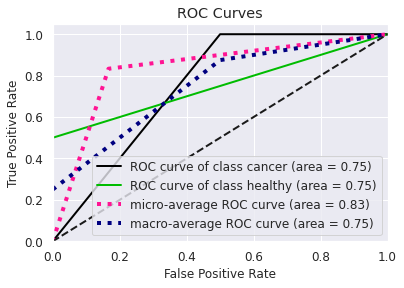

In [17]:
import scikitplot as skplt
skplt.metrics.plot_roc_curve(y_test, sgd_test_score)

[[4 0]
 [2 0]]


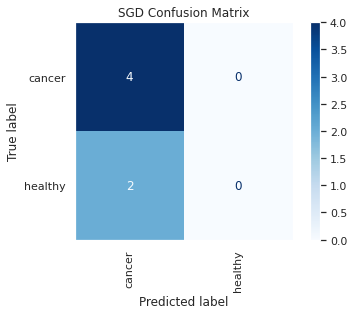

In [18]:
from sklearn.metrics import plot_confusion_matrix

class_names = ['cancer', 'healthy']

disp = plot_confusion_matrix(sgd, X_test, y_test,
                            display_labels = class_names,
                            cmap=plt.cm.Blues, xticks_rotation='vertical')

disp.ax_.set_title("SGD Confusion Matrix")

print(disp.confusion_matrix)
plt.grid(False)
plt.show()

In [19]:
print("***** Train Set *****")
print_accuracy_and_classification_report(Y_one_hot, predict_classes(sgd_train_score))
print("****** Test Set ******")
print_accuracy_and_classification_report(Y_test_labels, predict_classes(sgd_test_score))

***** Train Set *****
Cross validation accuracy:
	 0.5555555555555556

Cross validation classification report

              precision    recall  f1-score   support

           0       0.62      0.83      0.71         6
           1       0.00      0.00      0.00         3

    accuracy                           0.56         9
   macro avg       0.31      0.42      0.36         9
weighted avg       0.42      0.56      0.48         9

****** Test Set ******
Cross validation accuracy:
	 0.8333333333333334

Cross validation classification report

              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.50      0.67         2

    accuracy                           0.83         6
   macro avg       0.90      0.75      0.78         6
weighted avg       0.87      0.83      0.81         6



## Classification - AdaBoost

In [20]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100)
ada_fit = ada.fit(X_train, y_train)

ada_test_score = cross_val_predict(ada_fit, X_test, Y_test_labels, cv = loo, method='predict_proba')
ada_train_score = cross_val_predict(ada_fit, X_train, Y_one_hot, cv = loo, method='predict_proba')

#ada_test_score = ada_fit.predict_proba(X_test)
#ada_train_score = ada_fit.predict_proba(X_train)

/usr/local/lib/python3.6/dist-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


/usr/local/lib/python3.6/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; This will be removed in v0.5.0. Please use scikitplot.metrics.plot_roc instead.
  warnings.warn(msg, category=FutureWarning)


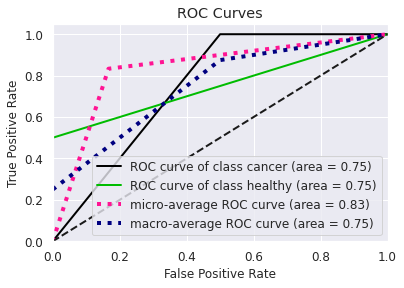

In [21]:
import scikitplot as skplt
skplt.metrics.plot_roc_curve(y_test, ada_test_score)

[[4 0]
 [0 2]]


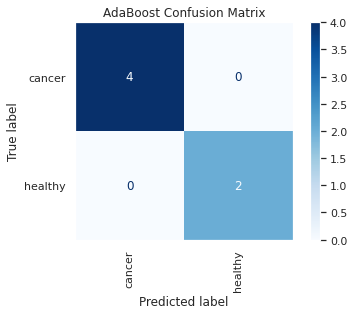

In [22]:
from sklearn.metrics import plot_confusion_matrix

class_names = ['cancer', 'healthy']

disp = plot_confusion_matrix(ada_fit, X_test, y_test,
                            display_labels = class_names,
                            cmap=plt.cm.Blues, xticks_rotation='vertical')

disp.ax_.set_title("AdaBoost Confusion Matrix")

print(disp.confusion_matrix)
plt.grid(False)
plt.show()

In [23]:
print("***** Train Set *****")
print_accuracy_and_classification_report(Y_one_hot, predict_classes(ada_train_score))
print("****** Test Set ******")
print_accuracy_and_classification_report(Y_test_labels, predict_classes(ada_test_score))

***** Train Set *****
Cross validation accuracy:
	 0.8888888888888888

Cross validation classification report

              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.75      1.00      0.86         3

    accuracy                           0.89         9
   macro avg       0.88      0.92      0.88         9
weighted avg       0.92      0.89      0.89         9

****** Test Set ******
Cross validation accuracy:
	 0.8333333333333334

Cross validation classification report

              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.50      0.67         2

    accuracy                           0.83         6
   macro avg       0.90      0.75      0.78         6
weighted avg       0.87      0.83      0.81         6

